# U.S. Treasury ETF Rotation Strategy — Results

This notebook presents the results of the **Winner / Median / Loser** Treasury ETF rotation backtest.

| Ticker | Exposure | Maturity |
|--------|----------------------------------------------|----------------|
| SHV | iShares Short Treasury Bond ETF | 1–12 months |
| SHY | iShares 1–3 Year Treasury Bond ETF | 1–3 years |
| IEI | iShares 3–7 Year Treasury Bond ETF | 3–7 years |
| IEF | iShares 7–10 Year Treasury Bond ETF | 7–10 years |
| TLH | iShares 10–20 Year Treasury Bond ETF | 10–20 years |
| TLT | iShares 20+ Year Treasury Bond ETF | 20+ years |

**Benchmark:** Bloomberg U.S. Treasury Total Return Index (LUATTRUU)  
**Period:** January 2008 – March 2025  
**Initial investment:** $100

## 1. Setup & Run Backtest

Import the modular source code and run all rebalancing frequencies.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from src.config import (
    ETFS, START_YEAR, END_YEAR, INITIAL_CASH, RF_ANNUAL,
    LUATTRUU_FILENAME, REBALANCING_SETTINGS,
)
from src.backtest import run_etf_rotation
from src.selection_table import semiannual_selection_table
from src.visualizations import (
    build_ref_buyhold, plot_final_values, plot_growth_curve,
    plot_all_growth_curves, plot_metric_bars,
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

In [2]:
# Run all rebalancing frequencies
runs = {}
for name, unit, freq in REBALANCING_SETTINGS:
    print(f'▶ {name} ({freq} {unit})')
    annual_df, _groups = run_etf_rotation(
        etfs=ETFS,
        start_year=START_YEAR,
        end_year=END_YEAR,
        initial_cash=INITIAL_CASH,
        rebalancing_unit=unit,
        rebalancing_frequency=freq,
        luattruu_filename=LUATTRUU_FILENAME,
        rf_annual=RF_ANNUAL,
        verbose=False,
        save_csv=True,
    )
    if annual_df is not None and not annual_df.empty:
        runs[(unit, freq)] = (name, annual_df)

ref = build_ref_buyhold(runs, prefer=('months', 12))
print(f'\n✅ {len(runs)} frequencies loaded.')

▶ Annual (12 months)
▶ Semi-Annual (6 months)
▶ Quarterly (3 months)
▶ Monthly (1 months)
▶ Bi-Weekly (2 weeks)
▶ Weekly (1 weeks)
▶ Daily (1 days)

✅ 7 frequencies loaded.


## 2. Annual Summary Tables

Year-end portfolio values and returns for each rebalancing frequency.

In [3]:
import pandas as pd

for name, unit, freq in REBALANCING_SETTINGS:
    key = (unit, freq)
    if key not in runs:
        continue
    _, df = runs[key]
    display_cols = ['Winners', 'Median', 'Losers', 'BuyHold_2',
                    'Return_Winners', 'Return_Median', 'Return_Losers', 'Return_BuyHold_2']
    cols = [c for c in display_cols if c in df.columns]
    print(f'\n{"="*60}')
    print(f'{name} Rebalancing')
    print(f'{"="*60}')
    display(df[cols].round(2))


Annual Rebalancing


,Winners,Median,Losers,BuyHold_2,Return_Winners,Return_Median,Return_Losers,Return_BuyHold_2
Year,,,,,,,,
2008,115.78,115.78,115.78,113.74,NaN,NaN,NaN,NaN
2009,97.89,110.97,116.07,109.68,-15.45,-4.15,0.25,-3.57
2010,99.06,119.68,126.91,116.12,1.20,7.84,9.34,5.87
2011,117.54,145.00,127.87,127.51,18.65,21.16,0.75,9.81
2012,121.04,148.96,128.05,130.06,2.97,2.73,0.14,1.99
2013,112.35,137.62,128.18,126.48,-7.18,-7.61,0.10,-2.75
2014,112.59,146.04,154.83,132.88,0.22,6.12,20.79,5.05
2015,112.37,148.34,155.18,134.00,-0.20,1.58,0.22,0.84
2016,113.62,149.57,156.40,135.38,1.11,0.83,0.79,1.04



Semi-Annual Rebalancing


,Winners,Median,Losers,BuyHold_2,Return_Winners,Return_Median,Return_Losers,Return_BuyHold_2
Year,,,,,,,,
2008,114.60,113.65,119.14,113.74,NaN,NaN,NaN,NaN
2009,98.56,108.92,117.33,109.68,-14.00,-4.16,-1.52,-3.57
2010,98.68,114.37,133.35,116.12,0.12,5.01,13.65,5.87
2011,115.48,137.75,137.15,127.51,17.03,20.44,2.85,9.81
2012,118.92,141.51,137.35,130.06,2.98,2.73,0.14,1.99
2013,115.64,139.87,122.46,126.48,-2.76,-1.16,-10.84,-2.75
2014,126.72,148.40,135.19,132.88,9.58,6.10,10.39,5.05
2015,122.73,150.32,140.05,134.00,-3.15,1.29,3.60,0.84
2016,124.05,152.03,140.91,135.38,1.08,1.13,0.61,1.04



Quarterly Rebalancing


...

,Winners,Median,Losers,BuyHold_2,Return_Winners,Return_Median,Return_Losers,Return_BuyHold_2
Year,,,,,,,,
2008,119.77,115.92,113.00,114.48,NaN,NaN,NaN,NaN
2009,109.38,113.13,105.75,111.15,-8.68,-2.41,-6.42,-2.91
2010,119.06,121.13,103.26,116.12,8.85,7.08,-2.35,4.47
2011,139.67,136.80,112.33,127.51,17.32,12.93,8.78,9.81
2012,149.22,143.34,108.20,130.23,6.84,4.78,-3.67,2.13
2013,146.35,141.66,94.16,126.43,-1.93,-1.18,-12.98,-2.91
2014,162.39,152.17,99.85,132.30,10.96,7.42,6.04,4.64
2015,163.04,155.83,101.24,134.21,0.40,2.41,1.40,1.44
2016,163.79,154.24,101.99,134.64,0.46,-1.02,0.73,0.33



Weekly Rebalancing


,Winners,Median,Losers,BuyHold_2,Return_Winners,Return_Median,Return_Losers,Return_BuyHold_2
Year,,,,,,,,
2008,120.78,114.29,113.08,114.32,NaN,NaN,NaN,NaN
2009,100.60,107.99,115.05,109.86,-16.70,-5.51,1.74,-3.90
2010,106.76,113.10,123.41,116.12,6.12,4.73,7.26,5.70
2011,110.42,127.53,152.66,127.51,3.43,12.76,23.70,9.81
2012,108.02,130.96,163.88,130.23,-2.17,2.70,7.35,2.13
2013,92.00,128.47,165.48,126.43,-14.83,-1.91,0.97,-2.91
2014,96.77,135.18,188.97,132.30,5.19,5.23,14.20,4.64
2015,93.29,135.95,203.15,134.21,-3.59,0.57,7.51,1.44
2016,89.91,137.90,211.43,135.38,-3.62,1.43,4.07,0.88



Daily Rebalancing


,Winners,Median,Losers,BuyHold_2,Return_Winners,Return_Median,Return_Losers,Return_BuyHold_2
Year,,,,,,,,
2008,129.81,110.75,106.91,113.74,NaN,NaN,NaN,NaN
2009,122.38,103.62,98.31,109.68,-5.72,-6.44,-8.04,-3.57
2010,119.76,113.11,109.92,116.12,-2.14,9.16,11.82,5.87
2011,142.41,127.30,118.48,127.51,18.91,12.55,7.78,9.81
2012,153.31,129.51,114.70,130.06,7.66,1.73,-3.18,1.99
2013,131.39,125.09,118.81,126.48,-14.30,-3.41,3.58,-2.75
2014,139.66,133.30,134.56,132.88,6.30,6.56,13.26,5.05
2015,139.93,138.11,131.86,134.00,0.19,3.60,-2.01,0.84
2016,134.84,139.45,139.36,135.38,-3.64,0.97,5.69,1.04


## 3. Semi-Annual Membership Table

Which ETFs are assigned to Winners / Median / Losers each half-year.

In [4]:
membership_df = semiannual_selection_table(
    etfs=ETFS,
    start_year=START_YEAR,
    end_year=END_YEAR,
    drop_years=[START_YEAR],
)
display(membership_df)

  → Saved: results/tables/semi_annual_memberships.csv


Winners              Median              Losers          
            H1        H2        H1        H2        H1        H2
Year                                                            
2009  TLH, TLT  SHY, SHV  IEI, IEF  IEF, IEI  SHV, SHY  TLT, TLH
2010  SHY, IEI  TLH, TLT  IEF, SHV  IEI, IEF  TLT, TLH  SHV, SHY
2011  SHY, IEI  TLH, IEF  IEF, SHV  TLT, IEI  TLT, TLH  SHV, SHY
2012  TLH, TLT  TLH, TLT  IEI, IEF  IEI, IEF  SHV, SHY  SHV, SHY
2013  IEI, IEF  SHY, SHV  SHV, SHY  IEF, IEI  TLT, TLH  TLT, TLH
2014  SHV, SHY  TLH, TLT  IEF, IEI  IEI, IEF  TLT, TLH  SHV, SHY
2015  TLH, TLT  SHY, IEI  IEI, IEF  IEF, SHV  SHV, SHY  TLT, TLH
2016  TLH, TLT  TLH, TLT  IEI, IEF  IEI, IEF  SHY, SHV  SHV, SHY
2017  SHY, SHV  TLH, TLT  IEF, IEI  IEI, IEF  TLT, TLH  SHV, SHY
2018  TLH, TLT  SHY, SHV  IEF, SHV  IEF, IEI  IEI, SHY  TLT, TLH
2019  TLH, IEF  TLH, TLT  TLT, IEI  IEI, IEF  SHV, SHY  SHV, SHY
2020  TLH, TLT  TLH, TLT  IEI, IEF  IEI, IEF  SHY, SHV  SHV, SHY
2021  IEI, SHY  SHY, SHV  IEF, SHV  IEF, IEI  TLT, TLH  TLT, TLH
2022  TLH, TLT  SHY, SHV  SHV, IEF  IEF, IEI  IEI, SHY  TLT, TLH
2023  SHY, SHV  TLH, TLT  IEF, IEI  IEF, SHV  TLT, TLH  SHY, IEI
2024  SHY, IEI  SHY, SHV  IEF, SHV  IEF, IEI  TLT, TLH  TLT, TLH
2025  SHV, SHY  IEI, IEF  IEF, IEI  SHY, TLH  TLT, TLH  TLT, SHV

## 4. Visualizations

### 4.1 Final Portfolio Values

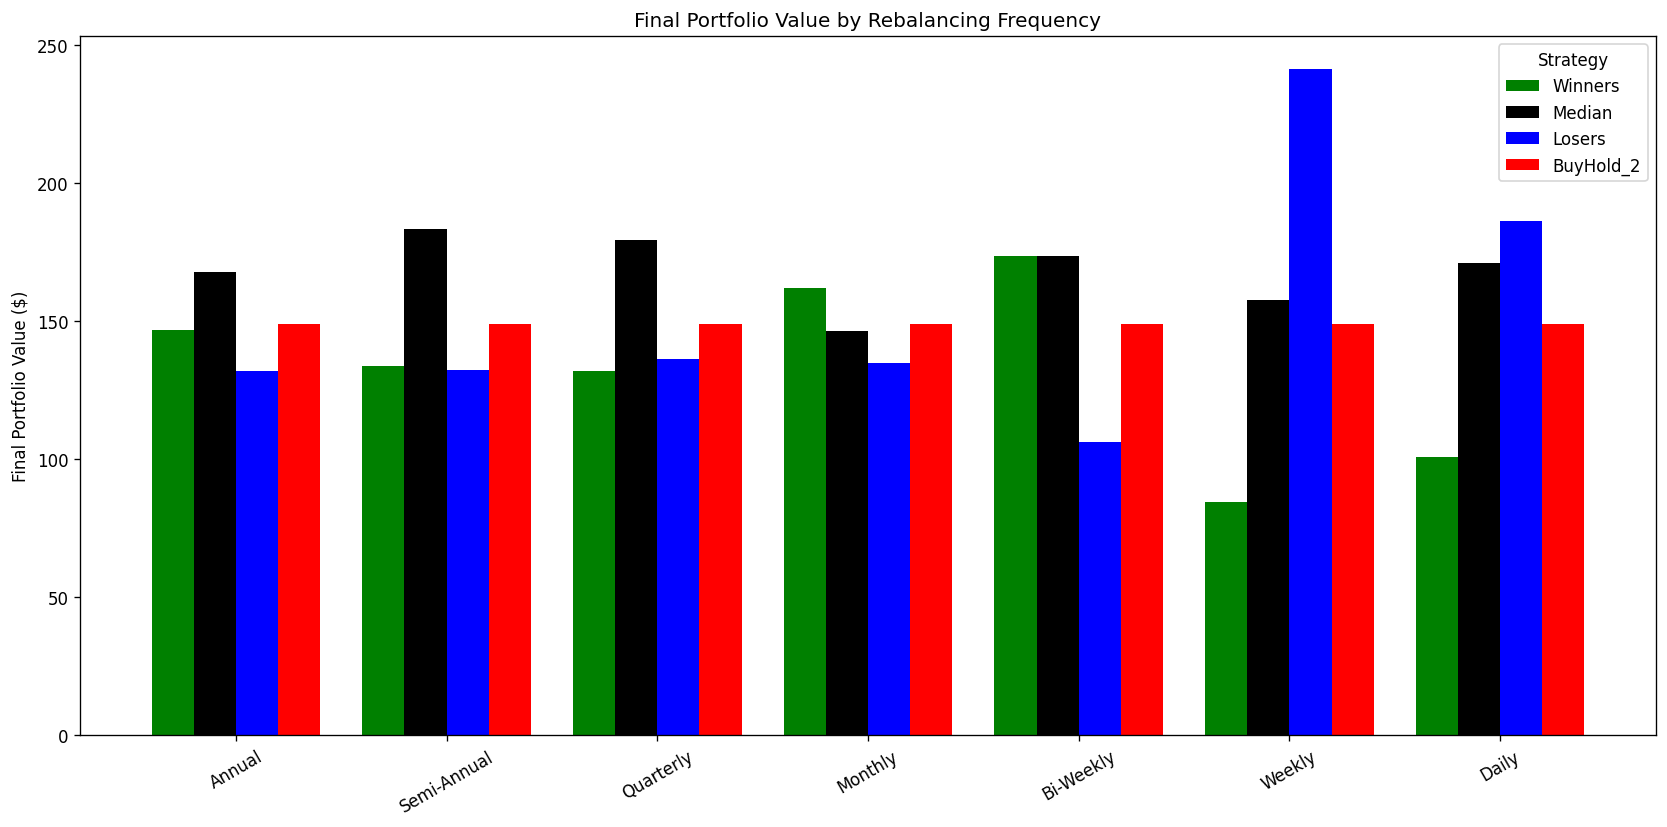

In [5]:
plot_final_values(runs, ref)

### 4.2 Growth Curves — Semi-Annual & Quarterly

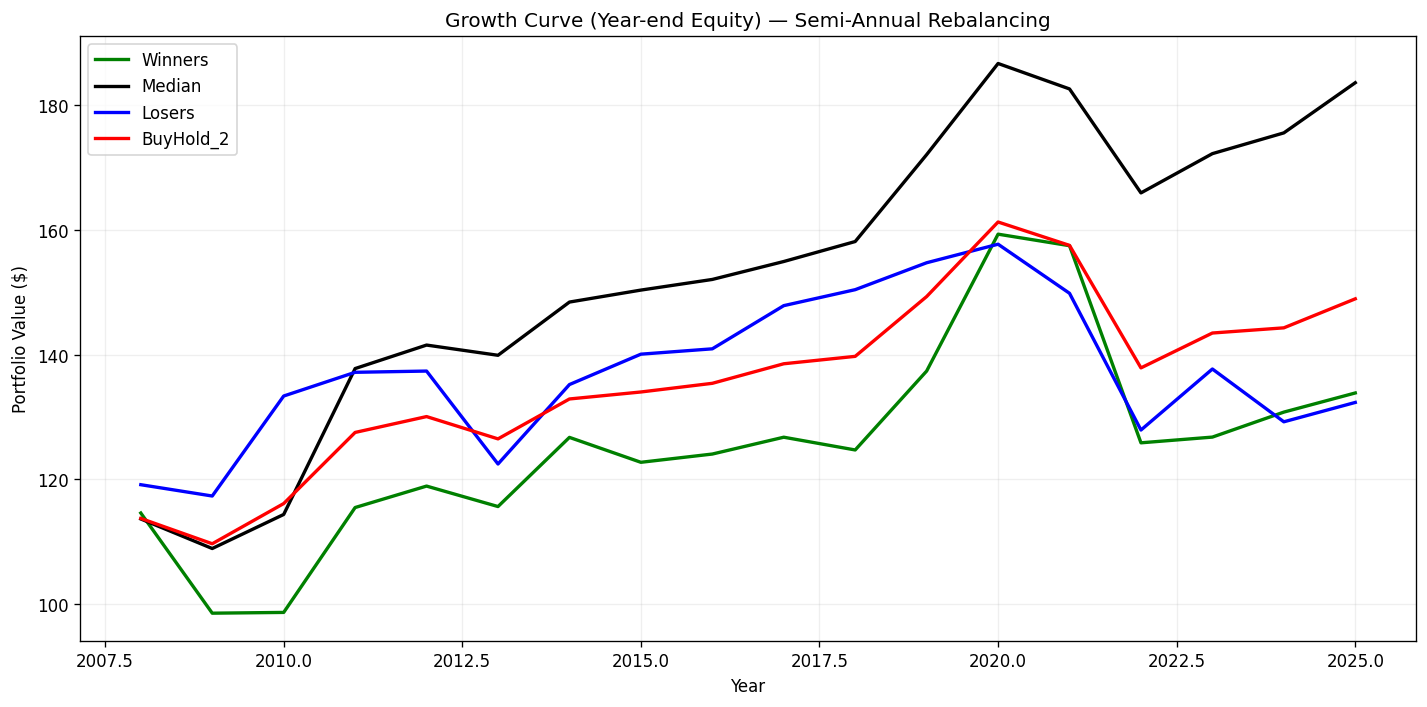

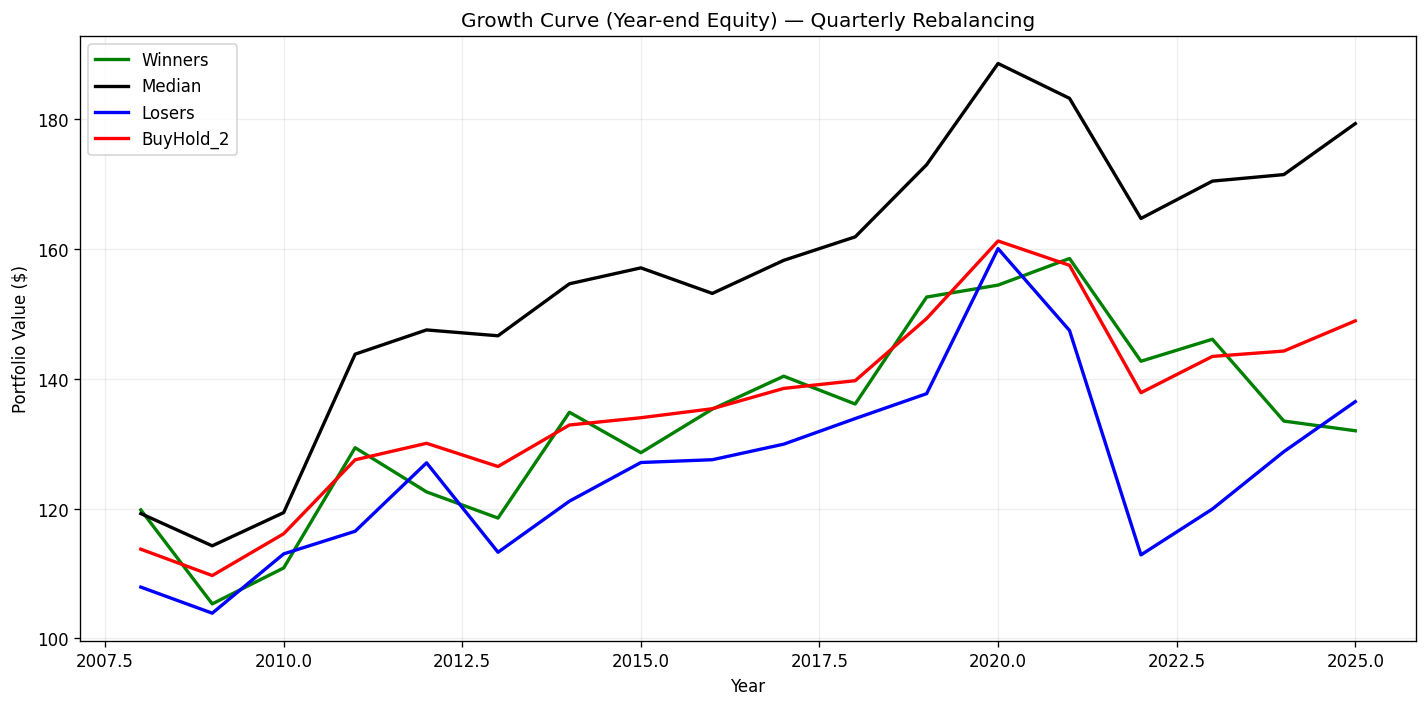

In [6]:
plot_growth_curve(runs, ref, 'Semi-Annual')
plot_growth_curve(runs, ref, 'Quarterly')

### 4.3 Growth Curves Dashboard — All Frequencies

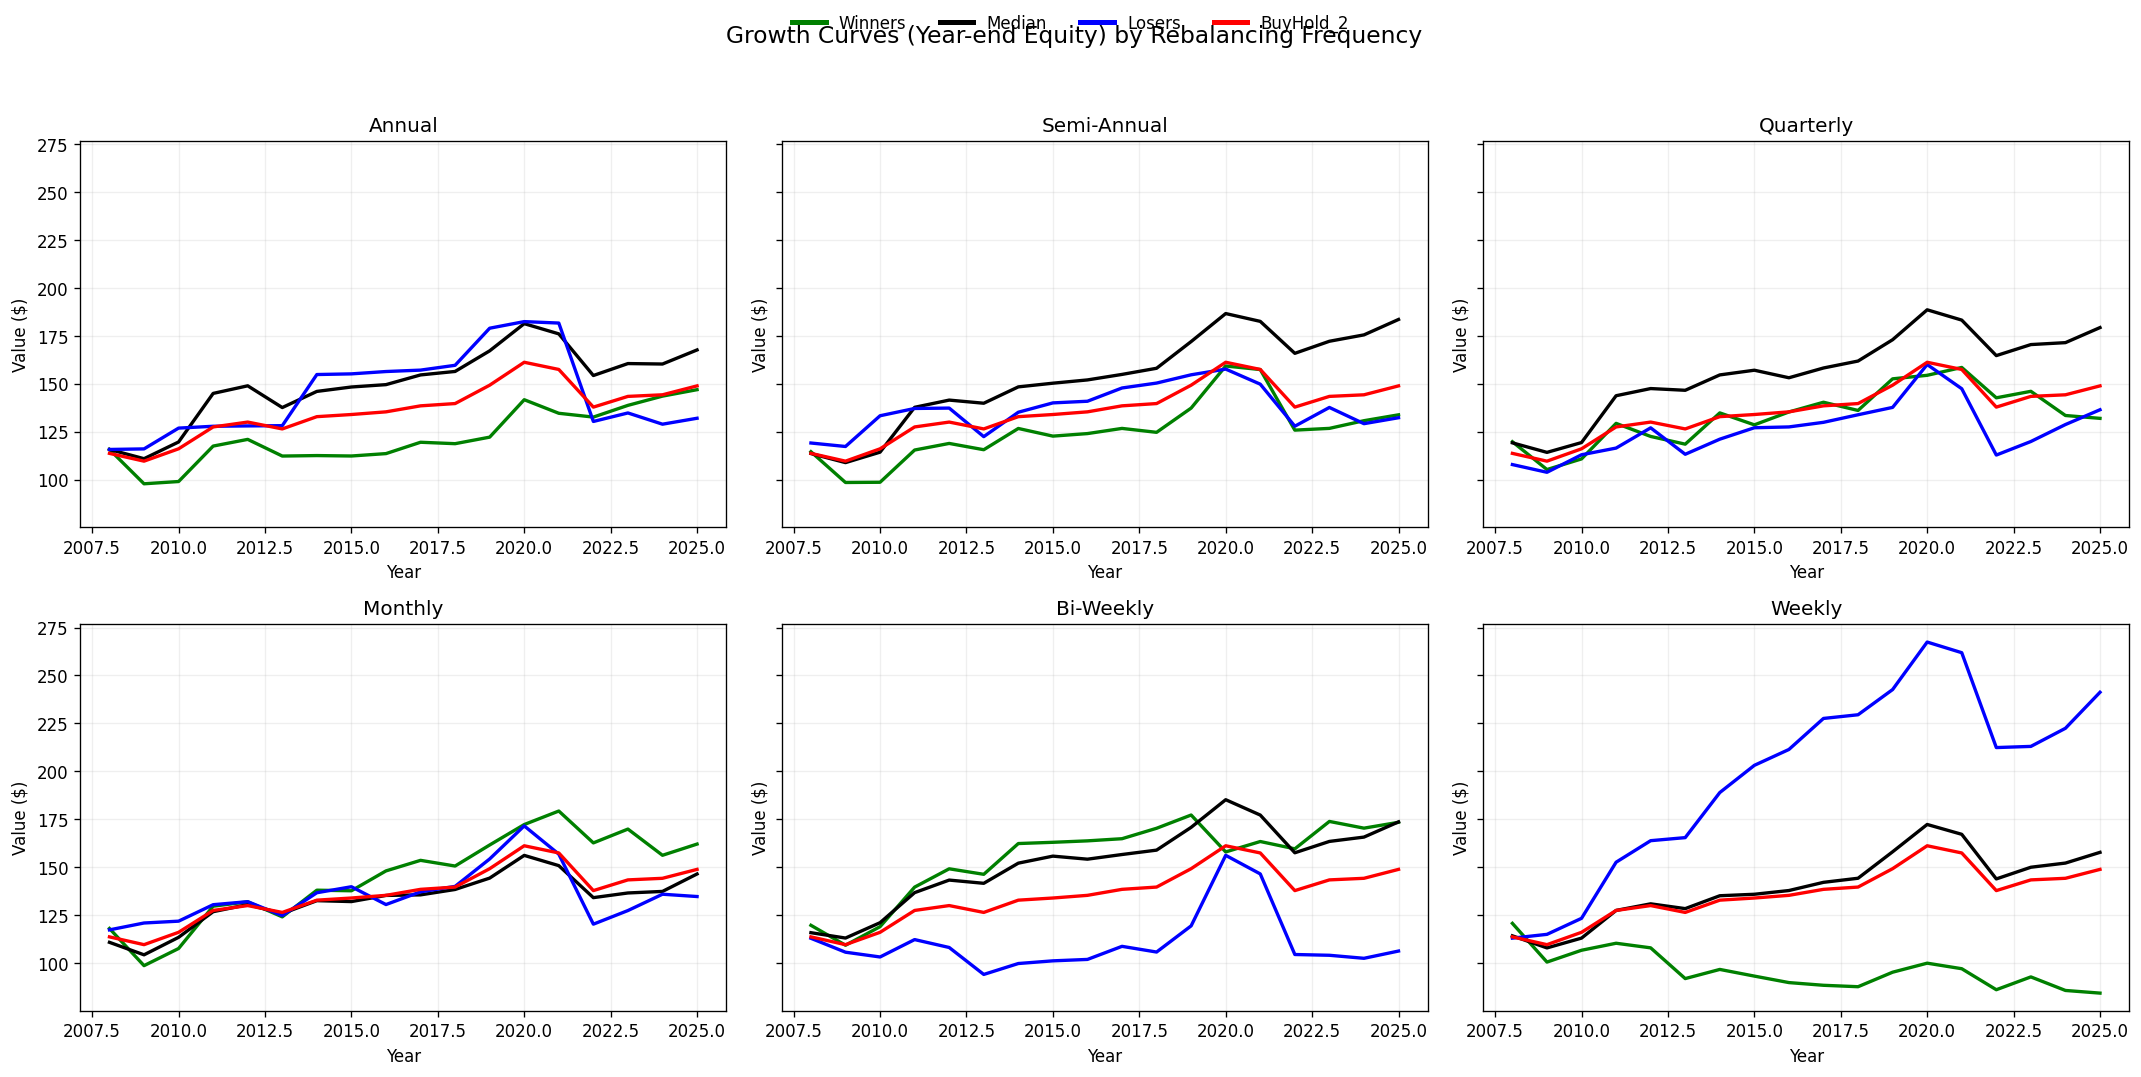

In [7]:
plot_all_growth_curves(runs, ref)

### 4.4 Performance Metrics Comparison

Annual Return, Sharpe Ratio, Volatility, and Max Drawdown across frequencies.

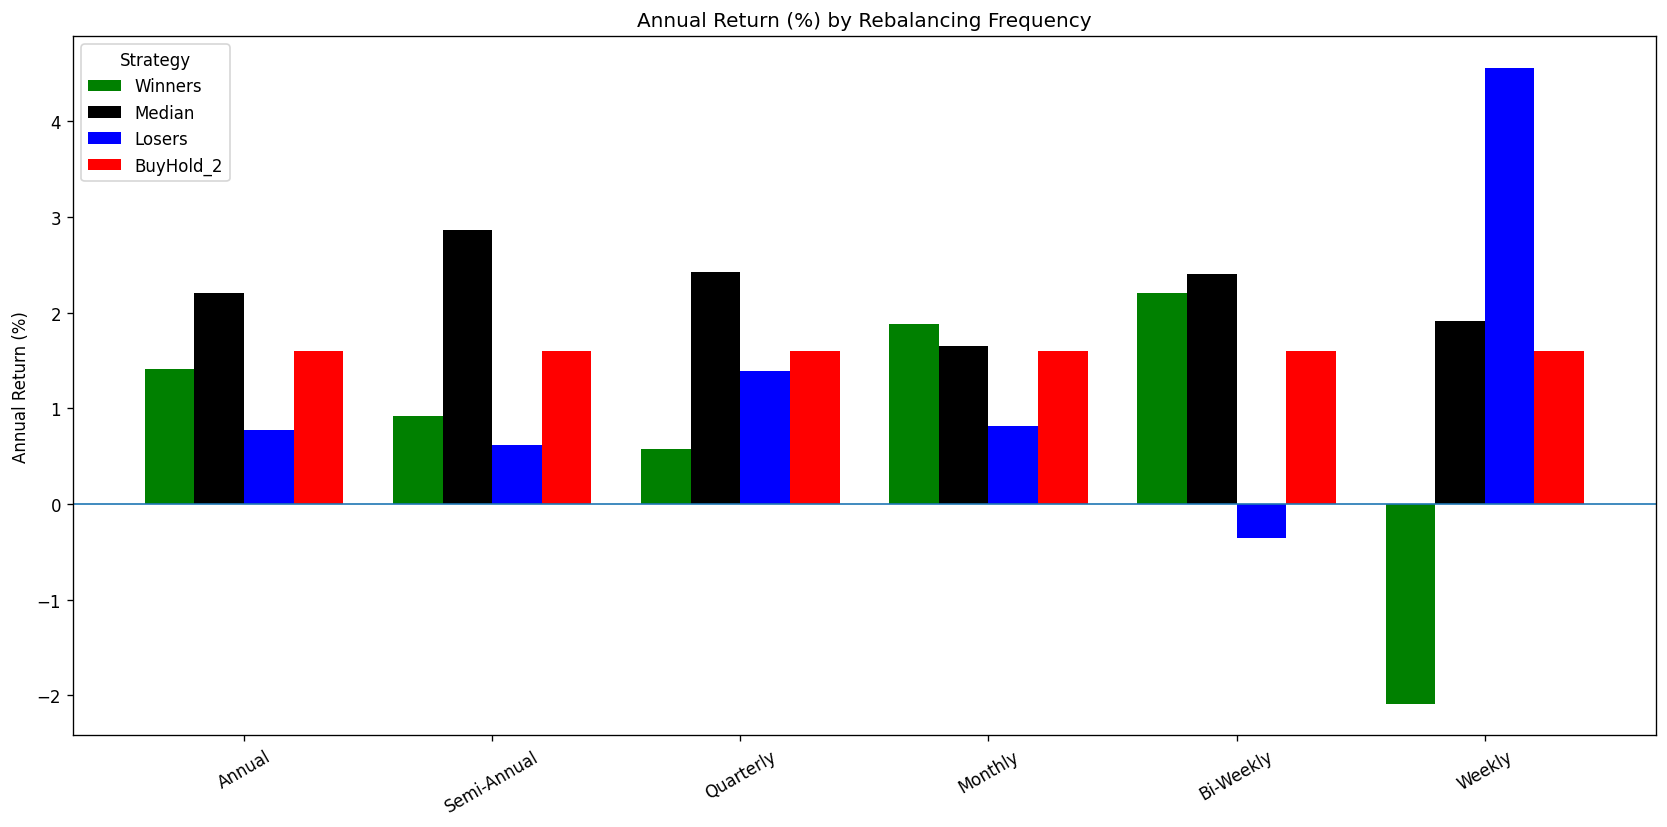

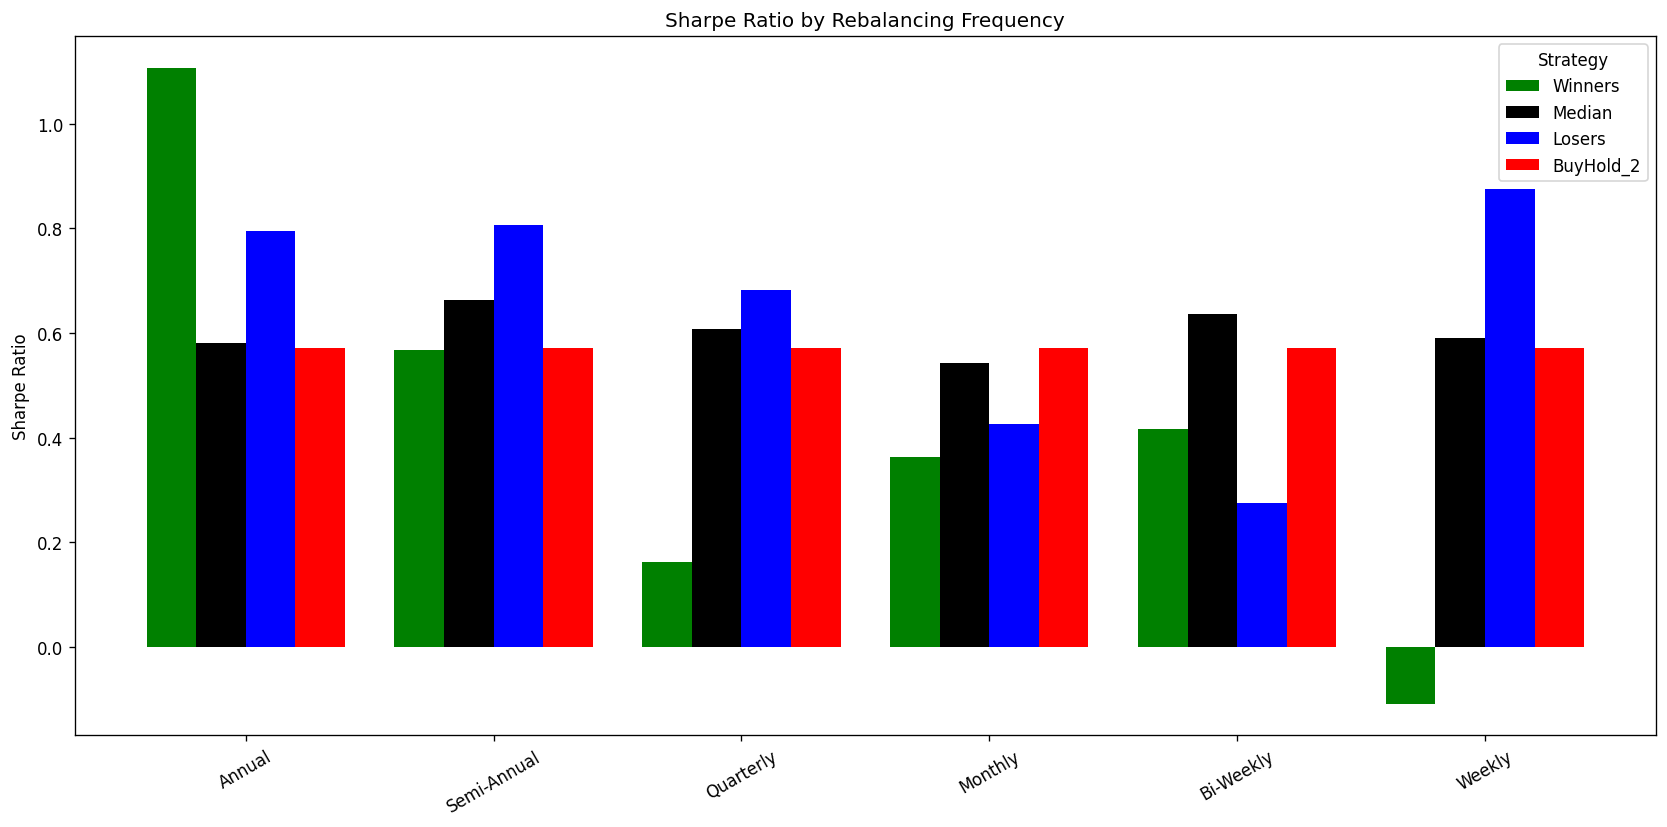

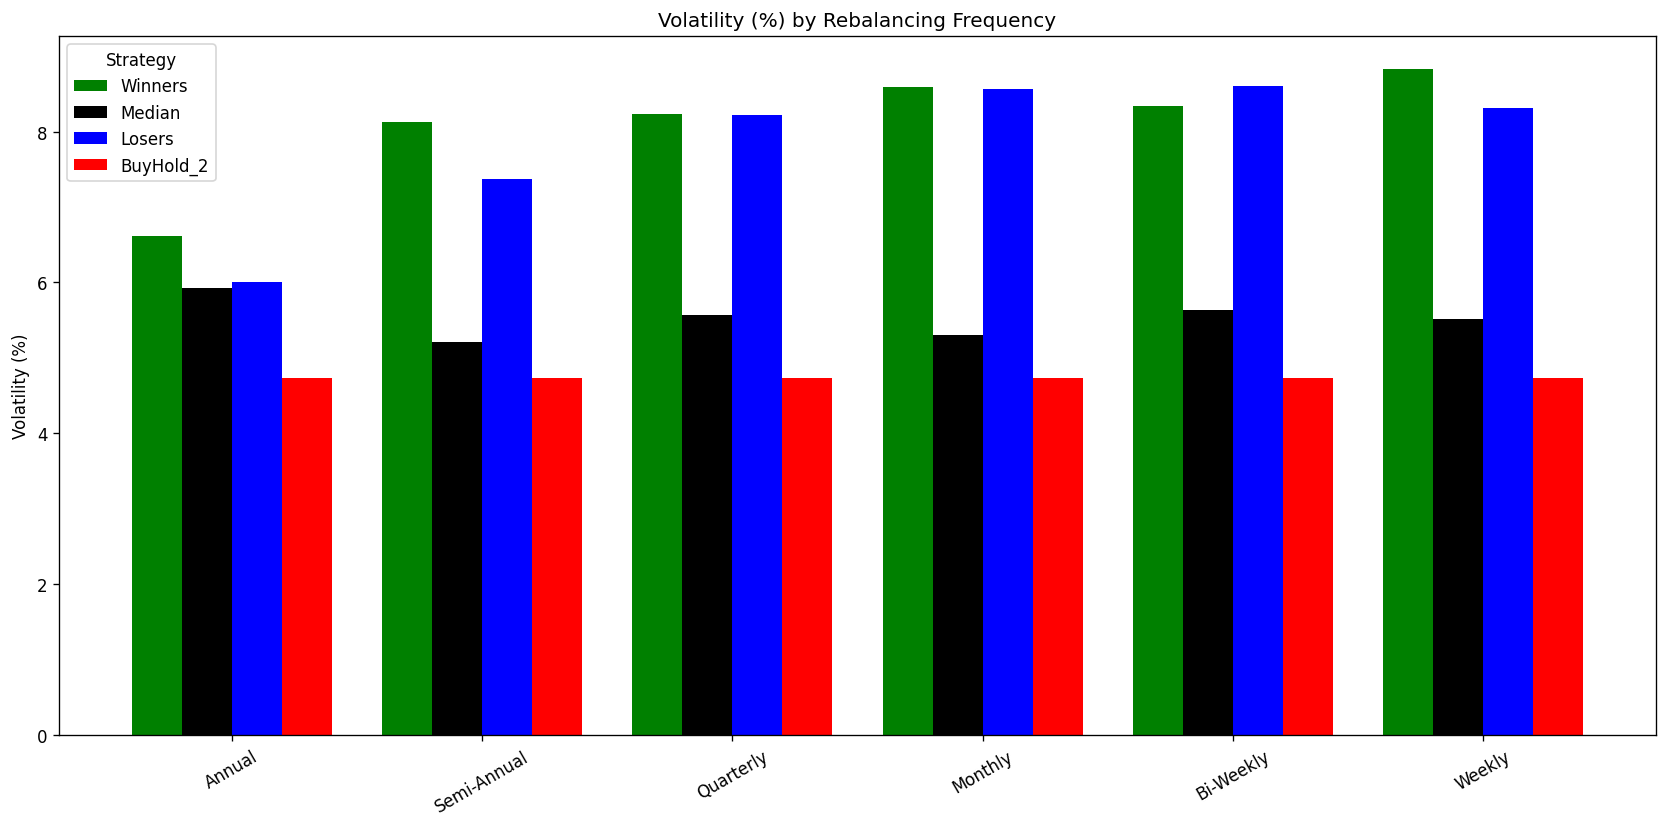

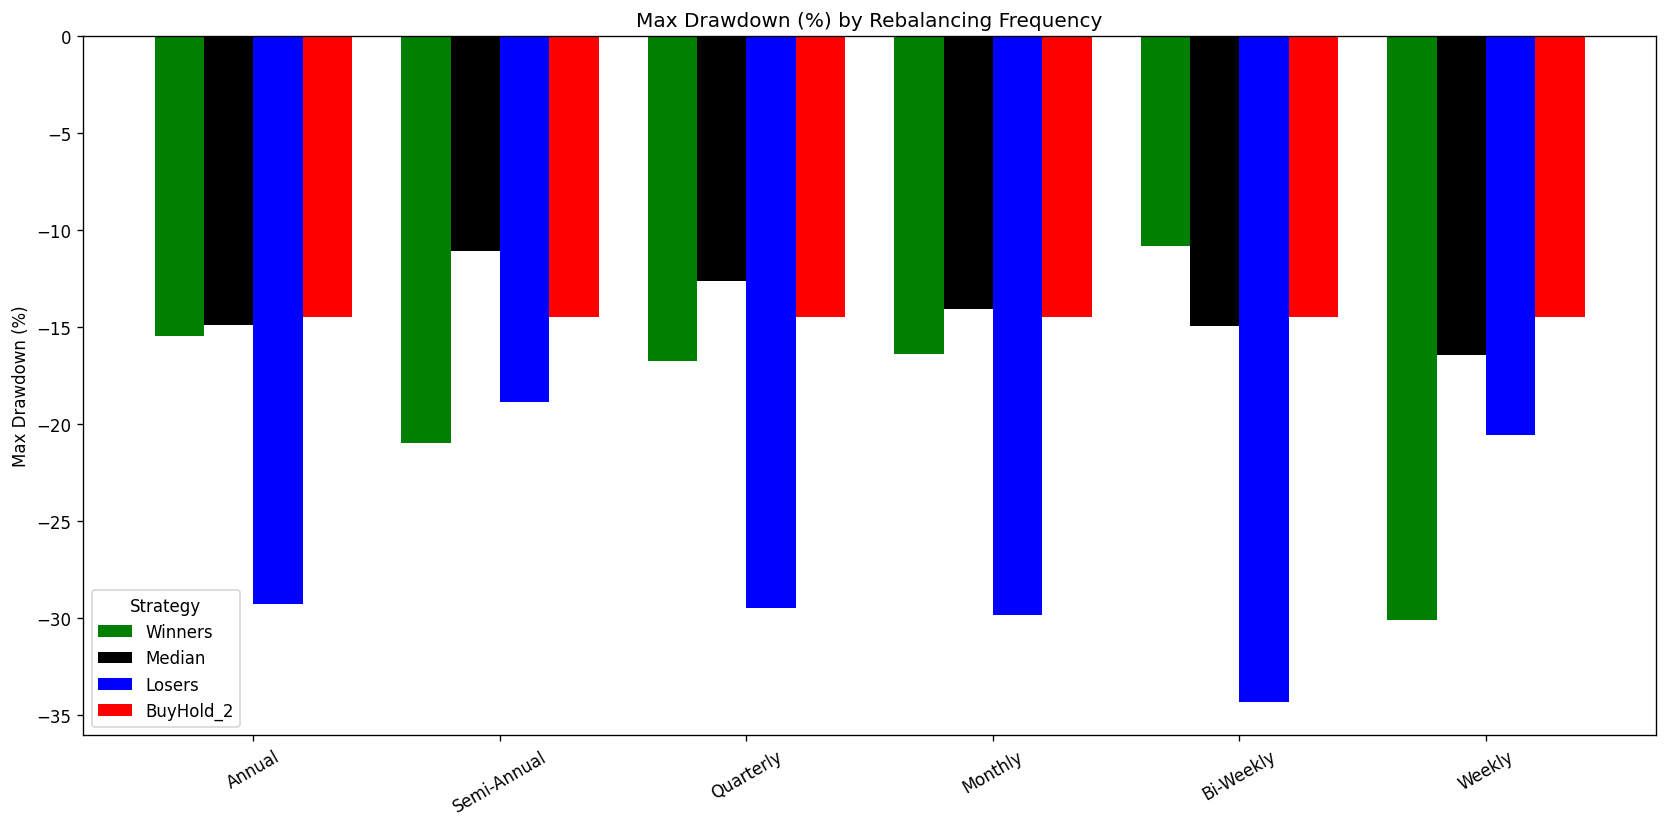

In [8]:
plot_metric_bars(runs, ref)

## 5. Key Findings

| Metric | Winners | Median | Losers | Buy & Hold |
|--------|---------|--------|--------|------------|
| Best frequency | Varies | **Semi-Annual** | Varies | N/A |
| Risk profile | High duration risk | Moderate | Low duration | Passive |

The **Median strategy with semi-annual rebalancing** achieves the best balance between return and risk by investing in mid-performing maturities, avoiding overexposure to duration risk while capturing consistent compounding growth.